# Introduction to Building a Compartmental Model


## 1. Let’s build the **basic SIR model**

Recall:

![modle](model_example.jpeg)

We split the population into three compartments:

* S(t): susceptible
* I(t): infected
* R(t): recovered

Total population:
$
N = S + I + R
$

#### The differential equations

$
\frac{dS}{dt} = -\beta \frac{S I}{N}
$

$
\frac{dI}{dt} = \beta \frac{S I}{N} - \gamma I
$

$
\frac{dR}{dt} = \gamma I
$


#### What the parameters mean

* **β (beta)** = infection rate
  - how fast the disease spreads when people meet

* **γ (gamma)** = recovery rate
  - how fast infected people recover


#### What `solve_ivp` Does
`scipy.integrate.solve_ivp`<br>

This function:

- numerically solves differential equations
- computes population values over time
- creates the outbreak simulation

Because these equations usually cannot be solved easily by hand.

```
sol = solve_ivp(
    fun,
    t_span,
    y0,
    args=(),
    t_eval=None,
    method='RK45',
    ...
)
```
| Parameter      | Type          | What it does                                         | Example                               |
| -------------- | ------------- | ---------------------------------------------------- | ------------------------------------- |
| `fun`          | function      | The differential equation function (dy/dt = f(t, y)) | `sir`                                 |
| `t_span`       | tuple         | Time interval ((t_0, t_f)) for solving               | `(0, 160)`                            |
| `y0`           | array-like    | Initial conditions at (t_0)                          | `[999, 1, 0]`                         |
| `args`         | tuple         | Extra parameters passed into `fun`                   | `(beta, gamma, N)`                    |
| `t_eval`       | array-like    | Specific time points to return solution at           | `np.linspace(0,160,1000)`             |
| `method`       | string        | Numerical solver method                              | `"RK45"` (default), `"RK23"`, `"BDF"` |
| `rtol`         | float         | Relative tolerance (accuracy control)                | `1e-3`                                |
| `atol`         | float         | Absolute tolerance (accuracy control)                | `1e-6`                                |
| `dense_output` | bool          | Whether to create continuous solution function       | `True` / `False`                      |
| `events`       | function/list | Detect events (e.g., infection peak time)            | custom event function                 |
| `vectorized`   | bool          | If `fun` supports vectorized inputs                  | `False` (default)                     |

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [ ]:
# SIR model functions
def sir(t, y, beta, gamma, N):
    S, I, R = y

    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I

    return [dSdt, dIdt, dRdt]

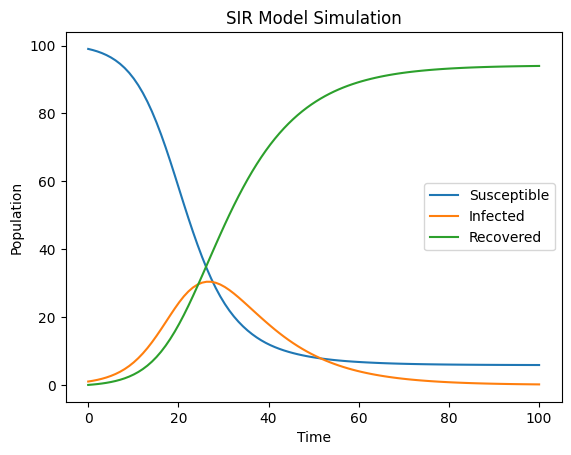

In [ ]:
# Parameters
N = 100        # total poplulation
beta = 0.3     # infection rate
gamma = 0.1    # recovery rate

# Initial population
S0 = 99
I0 = 1
R0 = 0

y0 = [S0, I0, R0]

# Time span
total_day = 100
intervals = 100
t_span = (0, total_day) # Simulate the SIR model from day 0 to day 50

# how smooth your plotted curve will look
t_eval = np.linspace(0, total_day, intervals) # After solving, give me results at these 500 evenly spaced times.

# Solve ODE
sol = solve_ivp(
    sir,
    t_span,
    y0,
    args=(beta, gamma, N),
    t_eval=t_eval
)

# Extract results
S_pop, I_pop, R_pop = sol.y


# Plot
plt.plot(sol.t, S_pop, label="Susceptible")
plt.plot(sol.t, I_pop, label="Infected")
plt.plot(sol.t, R_pop, label="Recovered")

plt.xlabel("Time")
plt.ylabel("Population")
plt.title("SIR Model Simulation")
plt.legend()
plt.show()

below is a plot visualization of the simulation

do not need to understand the code

In [ ]:
S_pop, I_pop, R_pop = sol.y

# Create a Structured Grid for the Dots (coordinates for each dot)
# N = 100
grid_cols = N/10
grid_rows = 10
x_coords, y_coords = np.meshgrid(np.arange(grid_cols), np.arange(grid_rows))
x_coords = x_coords.flatten()
y_coords = y_coords.flatten()

# Define color palette
colors = {
    'S': '#1f77b4',
    'I': '#d62728',
    'R': '#2ca02c'
}

# Setup Plot
fig, ax = plt.subplots(figsize=(6, 6))
scatter = ax.scatter(x_coords, y_coords, c=['#1f77b4']*N, s=60, edgecolors='none')
ax.set_title("SIR Model Grid Simulation", fontsize=14, pad=15)
ax.axis('off')

# creates a text box on the plot that you can update during the simulation
stats_text = ax.text(0.5, -0.05, "", transform=ax.transAxes, ha="center", fontsize=12,
                     bbox=dict(boxstyle="round", facecolor="white"))

# Animation Update Function
def update(frame):
    # 1. Get population counts for this frame
    s_count = int(np.round(S_pop[frame]))
    i_count = int(np.round(I_pop[frame]))
    r_count = N - s_count - i_count

    # 2. Assign categories to match the calculated proportions
    states = (['S'] * s_count) + (['I'] * i_count) + (['R'] * r_count)

    # Shuffle randomly so the outbreak looks scattered across the community
    np.random.seed(frame)
    np.random.shuffle(states)

    # Map back to hex color strings
    frame_colors = [colors[state] for state in states]
    scatter.set_color(frame_colors)

    # Update the status bar below the grid
    stats_text.set_text(
        f"Day: {sol.t[frame]:.1f}  |  "
        f"Susceptible: {s_count}  |  "
        f"Infected: {i_count}  |  "
        f"Recovered: {r_count}"
    )

    return scatter, stats_text

# Run the animation
ani = FuncAnimation(fig, update, frames=len(t_eval), interval=50, blit=True)

plt.close()
HTML(ani.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

## 2. When zombies attack!: Mathematical modelling of an outbreak of zombie infection
Model a zombie invasion described in the paper by Munz et al.:

[Munz, Hudea, Imad, Smith, "When zombies attack!: mathematical modelling of an outbreak of zombie infection." In J.M. Tchuenche and C. Chiyaka, editors, Infectious Disease Modelling Research Progress, 133-150, 2009.](http://loe.org/images/content/091023/Zombie%20Publication.pdf)

<br>

For those interested, the original [code from the paper is here](https://scipy-cookbook.readthedocs.io/items/Zombie_Apocalypse_ODEINT.html). In this notebook will start with the basics, working code and modifying it to model more interesting scenarios.

#### The Compartments
| Symbol | Meaning                  |
| ------ | ------------------------ |
| (S)    | Susceptible humans       |
| (Z)    | Zombies                  |
| (R)    | Removed/dead individuals |

1. Susceptible Humans (S) These are healthy humans who: are alive, are not infected, can become zombies if attacked
2. Zombies (Z) These are infected zombies that: can attack humans, increase the zombie population, can sometimes be destroyed
3. Removed (R) These are: dead humans, destroyed zombies, individuals removed from the system. Depending on the model, some removed individuals may return as zombies later.


The model describes how populations change over time.

For example:

- Zombies bite humans
- Humans die
- Zombies are killed
- Dead bodies may resurrect

The simulation repeatedly updates the populations.

We will tract:
- total humans
- total zombies
- total removed

using differential equations

![zombie modle](zombie.png)

#### The Differential Equations

$\frac{dS}{dt} = P - βSZ - dS$

Where:

- P = birth rate
- β = infection rate
- S = number of humans
- Z = number of zombies
- SZ = encounters between humans and zombies
- d = natural death rate


$\frac{dZ}{dt} = βSZ + ζR − αSZ$

Where:
zombies increase when humans are infected
- R = removed/dead individuals
- ζ = resurrection rate
- α = zombie destruction rate


$\frac{dR}{dt} = dS + αSZ − ζR $
Removed individuals increase from deaths and destroyed zombies.

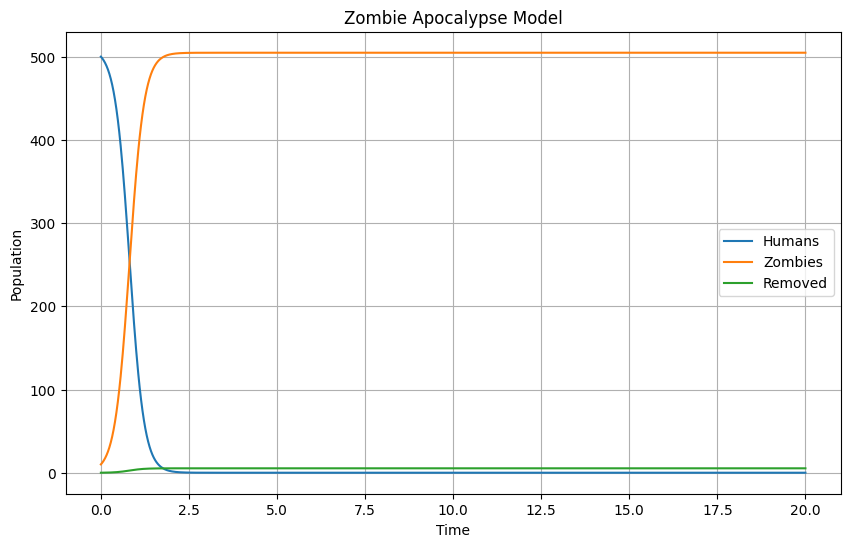

In [ ]:
# MODEL PARAMETERS
beta = 0.0095   # Infection rate
alpha = 0.0001  # Zombie destruction rate
zeta = 0.0001   # Resurrection rate
P = 0           # Natural human birth rate
d = 0.0001      # Natural human death rate

# INITIAL POPULATIONS
S0 = 500
Z0 = 10
R0 = 0

initial_conditions = [S0, Z0, R0]

# TIME SPAN
t_eval = np.linspace(0, 20, 1000)
t_span = (0, 20)

# DIFFERENTIAL EQUATIONS
def zombie_model(t, y, P, beta, d, alpha, zeta):

    S, Z, R = y

    # dS/dt
    dSdt = P - beta * S * Z - d * S

    # dZ/dt
    dZdt = beta * S * Z + zeta * R - alpha * S * Z

    # dR/dt
    dRdt = d * S + alpha * S * Z - zeta * R

    return [dSdt, dZdt, dRdt]

# SOLVE SYSTEM
solution = solve_ivp(
    zombie_model,
    t_span,
    initial_conditions,
    args=(P, beta, d, alpha, zeta),
    t_eval=t_eval
)

# EXTRACT RESULTS
t = solution.t
S = solution.y[0]
Z = solution.y[1]
R = solution.y[2]

# PLOT RESULTS
plt.figure(figsize=(10, 6))

plt.plot(t, S, label='Humans')
plt.plot(t, Z, label='Zombies')
plt.plot(t, R, label='Removed')

plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Zombie Apocalypse Model')

plt.legend()
plt.grid(True)

plt.show()

Modify the parameters, see how the model changes!

let us plot before and after bar graph to see how the population changed

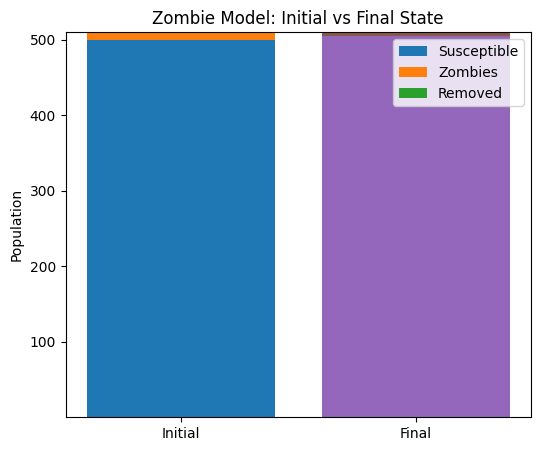

In [ ]:
# Initial populations
initial = [S0, Z0, R0]

# Final populations
final = [
    solution.y[0][-1],
    solution.y[1][-1],
    solution.y[2][-1]
]

labels = ["Susceptible", "Zombies", "Removed"]

fig, ax = plt.subplots(figsize=(6, 5))

# manually draw each stack
ax.bar(
    "Initial",
    initial[0],
    label=labels[0]
)

ax.bar(
    "Initial",
    initial[1],
    bottom=initial[0],
    label=labels[1]
)

ax.bar(
    "Initial",
    initial[2],
    bottom=initial[0] + initial[1],
    label=labels[2]
)


ax.bar(
    "Final",
    final[0]
)

ax.bar(
    "Final",
    final[1],
    bottom=final[0]
)

ax.bar(
    "Final",
    final[2],
    bottom=final[0] + final[1]
)


ax.set_ylabel("Population")
ax.set_title("Zombie Model: Initial vs Final State")

ax.legend()

plt.show()

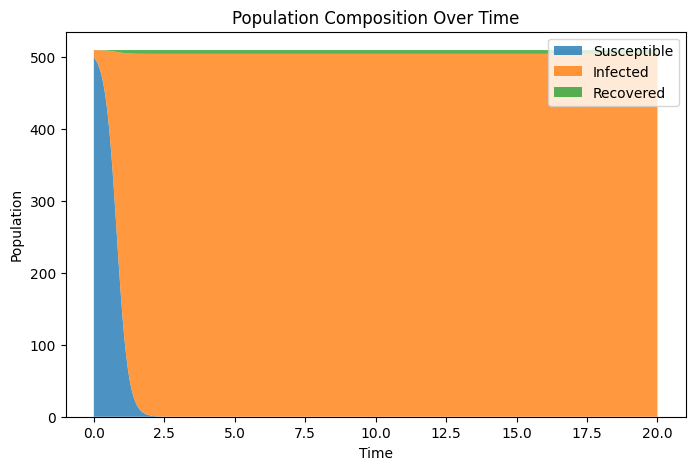

In [ ]:
# Area Chart (Stacked)
plt.figure(figsize=(8,5))

plt.stackplot(
    solution.t,
    solution.y[0],
    solution.y[1],
    solution.y[2],
    labels=["Susceptible", "Infected", "Recovered"],
    alpha=0.8
)

plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Population Composition Over Time")
plt.legend(loc="upper right")

plt.show()

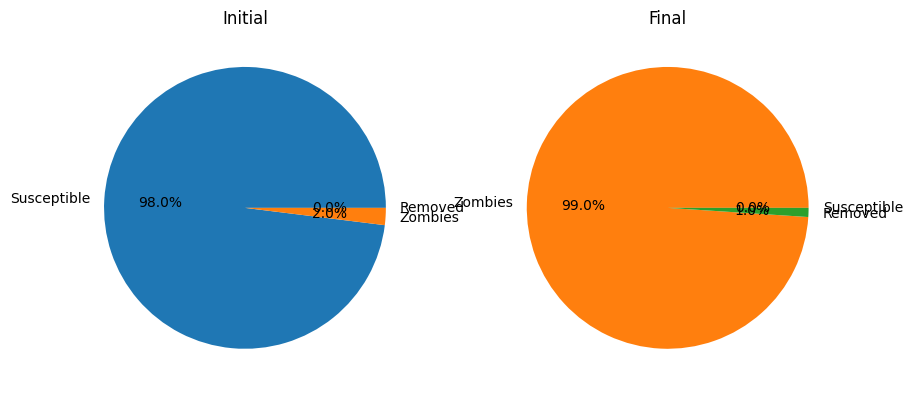

In [ ]:
# pie chart
fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].pie(initial, labels=labels, autopct="%1.1f%%")
ax[0].set_title("Initial")

ax[1].pie(final, labels=labels, autopct="%1.1f%%")
ax[1].set_title("Final")

plt.show()

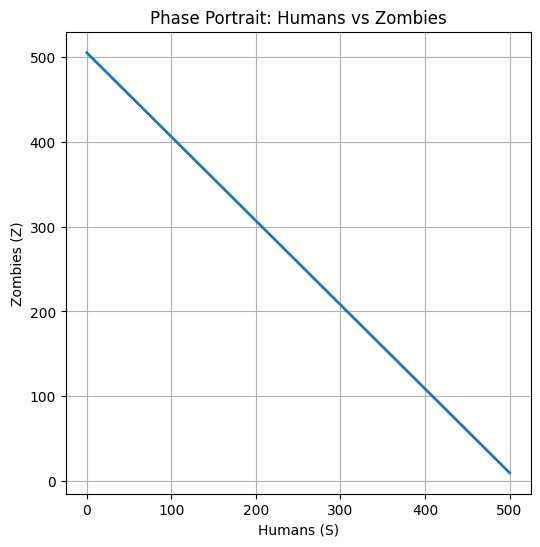

In [ ]:
plt.figure(figsize=(6,6))

plt.plot(S, Z, lw=2)

plt.xlabel("Humans (S)")
plt.ylabel("Zombies (Z)")
plt.title("Phase Portrait: Humans vs Zombies")

plt.grid(True)
plt.show()

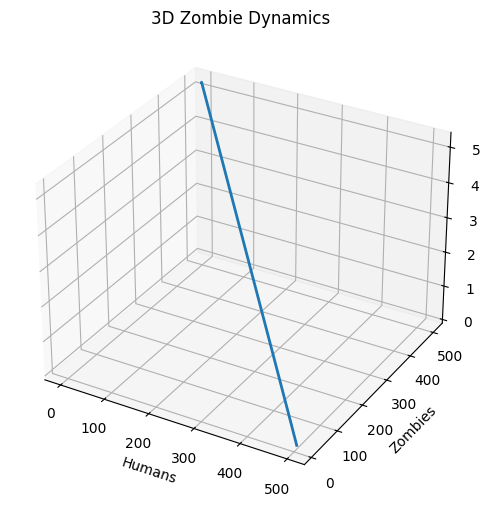

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot(S, Z, R, linewidth=2)

ax.set_xlabel("Humans")
ax.set_ylabel("Zombies")
ax.set_zlabel("Removed")

plt.title("3D Zombie Dynamics")
plt.show()

### 2.2 Zombie Model - more complicated

add `Vaccinated` class - Some humans get protection and cannot be infected.

Add:
- V(t) = vaccinated/immune humans
- ν = vaccination rate


### Updated system

$
\frac{dS}{dt} = P - \beta SZ - dS - \nu S
$

$
\frac{dZ}{dt} = \beta SZ + \zeta R - \alpha SZ
$

$
\frac{dR}{dt} = dS + \alpha SZ - \zeta R
$

$
\frac{dV}{dt} = \nu S - dV
$

![modle 2](zombie02.png)

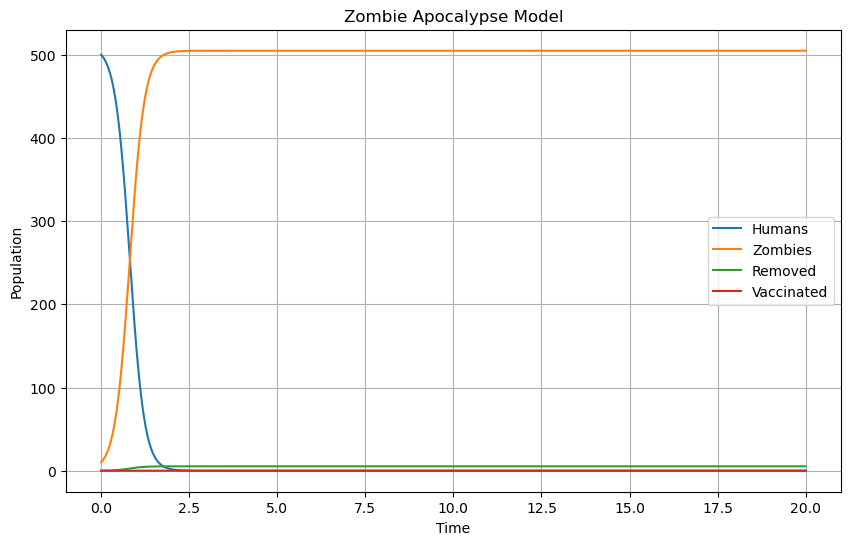

In [ ]:
# MODEL PARAMETERS
beta = 0.0095   # Infection rate
alpha = 0.0001  # Zombie destruction rate
zeta = 0.0001   # Resurrection rate
P = 0           # Natural human birth rate
d = 0.0001      # Natural human death rate
v = 0.0001      # Vaccination rate


# INITIAL POPULATIONS
S0 = 500      # humans
Z0 = 10        # zombies
R0 = 0        # removed/dead
V0 = 0        # vaccinated

initial_conditions = [S0, Z0, R0, V0]


# TIME SPAN
t_span = (0, 20) # (start, end) total 20 days
t_eval = np.linspace(0, 20, 1000) # Points where you want the solution. 1000 points between day 0 and day 20


# DIFFERENTIAL EQUATIONS (Note: t comes before y in the arguments)
def zombie_model(t, y, P, beta, d, alpha, zeta, v):

    S, Z, R, V = y

    # dS/dt
    dSdt = P - beta * S * Z - d * S

    # dZ/dt
    dZdt = beta * S * Z + zeta * R - alpha * S * Z

    # dR/dt
    dRdt = d * S + alpha * S * Z - zeta * R

    # dV/dt
    dVdt = v * S

    return [dSdt, dZdt, dRdt, dVdt]


# SOLVE SYSTEM
solution = solve_ivp(
    zombie_model,
    t_span,
    initial_conditions,
    t_eval=t_eval,
    args=(P, beta, d, alpha, zeta, v)
)

# Extract results from the solution object
S = solution.y[0]
Z = solution.y[1]
R = solution.y[2]
V = solution.y[3]
t = solution.t


# PLOT RESULTS
plt.figure(figsize=(10, 6))

plt.plot(t, S, label='Humans')
plt.plot(t, Z, label='Zombies')
plt.plot(t, R, label='Removed')
plt.plot(t, V, label='Vaccinated')

plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Zombie Apocalypse Model (solve_ivp)')

plt.legend()
plt.grid(True)

plt.show()